# Retrieval System

## Task: Built a two Tower (Query and Product) system
Matche a query to the fitting products based on:
1. The Title
2. the Description
3. The Bullet Points
4. The Brand
5. The Color
<br> Goal: </br>
1. Prioratize Products based on the pre-determined relevance (esci_label)
3. Past queries and past product-fits should influence the future results (RNN)
<br> Goal: Get as low of an overall Loss as possible

In [1]:
import torch
import os
if torch.cuda.is_available():
    #### Run on Gogle Colab
    # !pip install torch-ort
    # !python -m torch_ort.configure
    !python -m pip install lightning
    !python -m pip install imbalanced-learn
    pin_memory = False
    num_workers = os.cpu_count() - 2 if os.cpu_count() -2 > 3 else 3

    device = torch.device("cuda")
    accelerator = "gpu"


    from google.colab import drive
    drive.mount('/content/drive')
    data_dir = "/content/drive/MyDrive/Colab Data/RetrievalModel"
    # root_dir = "./drive/MyDrive/Colab Data/ResidualNeuralNetwork"
    torch.cuda.memory.empty_cache()
else:
    ### Run on my personal tower
    device = torch.device("cpu")
    accelerator = "cpu"
    data_dir = "EmbeddedData"
    # root_dir = "."

tensor_size = 32
torch.set_float32_matmul_precision("medium")
Project_Name = "RNN_Sentences_CE"
os.makedirs(f"Training_Progress/Logs/{Project_Name}", exist_ok = True)
os.makedirs(f"Training_Progress/Checkpoints/{Project_Name}", exist_ok = True)

## Explore Data

In [2]:
import numpy as np
import pandas as pd

Large_Dataset = pd.read_parquet(f"{data_dir}/SentenceEmbedding.parquet")
Large_Dataset

product_title                                                       \
                    0         1         2          3          4          5   
0           -4.079337  3.847864 -0.729618   3.138518   4.327556   3.357860   
1            3.893338  5.651582  2.524054   1.534307   1.740349   4.919367   
2           -1.541733  5.915594  2.462360   5.830202   0.057655   3.485694   
3            7.090992  7.519460 -1.712093  14.279944 -10.086328  12.536506   
4            6.522617  5.568812 -1.813076   8.262443   4.007835   1.429445   
...               ...       ...       ...        ...        ...        ...   
2621283      4.953020  1.788919  1.748300   0.622110  -3.231584   1.764582   
2621284      5.069838  1.883011 -0.424063  -2.065871  -4.235208   0.511501   
2621285      6.003750  0.395459  1.298870  -0.893088  -4.217788   0.959003   
2621286      6.003750  0.395459  1.298870  -0.893088  -4.217788   0.959003   
2621287      6.003750  0.395459  1.298870  -0.893088  -4.217788   0.959003   

                                                 ...      query             \
                6         7         8         9  ...         27         28   
0        1.216648  3.532077 -0.723933 -0.337356  ... -12.513047  15.264223   
1       -1.271370  2.135581  0.796760  1.958821  ... -12.513047  15.264223   
2       -1.508375  6.050313  2.976396  1.494216  ... -12.513047  15.264223   
3       -0.105441 -0.776574 -0.962799 -1.286689  ... -12.513047  15.264223   
4        2.572388  4.718240  1.622925  1.972882  ... -12.513047  15.264223   
...           ...       ...       ...       ...  ...        ...        ...   
2621283 -2.250641 -3.608654  0.817755  1.967357  ...  10.972528  -0.366776   
2621284  0.463555 -0.206944 -0.565094  0.898649  ...  10.972528  -0.366776   
2621285  2.384049 -2.821439  1.133335  1.409757  ...   6.753409   6.227701   
2621286  2.384049 -2.821439  1.133335  1.409757  ...  10.872013 -10.514281   
2621287  2.384049 -2.821439  1.133335  1.409757  ...  10.972528  -0.366776   

                                         product_id query_id example_id  \
                29         30        31                                   
0       -19.144426 -22.956654  7.925159  B079VKKJN7     1688      47092   
1       -19.144426 -22.956654  7.925159  B079Y9VRKS     1688      47091   
2       -19.144426 -22.956654  7.925159  B07DP4LM9H     1688      47089   
3       -19.144426 -22.956654  7.925159  B07G37B9HP     1688      47088   
4       -19.144426 -22.956654  7.925159  B07LCTGDHY     1688      47087   
...            ...        ...       ...         ...      ...        ...   
2621283  -5.341568   9.457088  3.555554  B09G72LDQZ   129052    2580177   
2621284  -5.341568   9.457088  3.555554  B09GBGRTPB   129052    2580178   
2621285   0.799776   0.190105  4.898800  B09GBKN83Q   123197    2433083   
2621286   1.899601   7.058802  0.403267  B09GBKN83Q   126351    2509401   
2621287  -5.341568   9.457088  3.555554  B09GBKN83Q   129052    2580179   

         split esci_label  
                           
0        train          E  
1        train          E  
2        train          E  
3        train          E  
4        train          E  
...        ...        ...  
2621283  train          S  
2621284  train          S  
2621285  train          S  
2621286  train          E  
2621287  train          S  

[2621288 rows x 229 columns]

In [3]:
esci_score_dict = {"E": 1.0,
                  "S": 0.75,
                  "C": 0.5,
                  "I": 0.25}

esci_LabelsEncoded_dict = {"E": 3,
                          "S": 2,
                          "C": 1,
                          "I": 0}



Large_Dataset.loc[:, "esci_label_encoded"] = Large_Dataset.loc[:, "esci_label"].apply(lambda x: esci_LabelsEncoded_dict[x])
Large_Dataset

product_title                                                       \
                    0         1         2          3          4          5   
0           -4.079337  3.847864 -0.729618   3.138518   4.327556   3.357860   
1            3.893338  5.651582  2.524054   1.534307   1.740349   4.919367   
2           -1.541733  5.915594  2.462360   5.830202   0.057655   3.485694   
3            7.090992  7.519460 -1.712093  14.279944 -10.086328  12.536506   
4            6.522617  5.568812 -1.813076   8.262443   4.007835   1.429445   
...               ...       ...       ...        ...        ...        ...   
2621283      4.953020  1.788919  1.748300   0.622110  -3.231584   1.764582   
2621284      5.069838  1.883011 -0.424063  -2.065871  -4.235208   0.511501   
2621285      6.003750  0.395459  1.298870  -0.893088  -4.217788   0.959003   
2621286      6.003750  0.395459  1.298870  -0.893088  -4.217788   0.959003   
2621287      6.003750  0.395459  1.298870  -0.893088  -4.217788   0.959003   

                                                 ...      query             \
                6         7         8         9  ...         28         29   
0        1.216648  3.532077 -0.723933 -0.337356  ...  15.264223 -19.144426   
1       -1.271370  2.135581  0.796760  1.958821  ...  15.264223 -19.144426   
2       -1.508375  6.050313  2.976396  1.494216  ...  15.264223 -19.144426   
3       -0.105441 -0.776574 -0.962799 -1.286689  ...  15.264223 -19.144426   
4        2.572388  4.718240  1.622925  1.972882  ...  15.264223 -19.144426   
...           ...       ...       ...       ...  ...        ...        ...   
2621283 -2.250641 -3.608654  0.817755  1.967357  ...  -0.366776  -5.341568   
2621284  0.463555 -0.206944 -0.565094  0.898649  ...  -0.366776  -5.341568   
2621285  2.384049 -2.821439  1.133335  1.409757  ...   6.227701   0.799776   
2621286  2.384049 -2.821439  1.133335  1.409757  ... -10.514281   1.899601   
2621287  2.384049 -2.821439  1.133335  1.409757  ...  -0.366776  -5.341568   

                              product_id query_id example_id  split  \
                30        31                                          
0       -22.956654  7.925159  B079VKKJN7     1688      47092  train   
1       -22.956654  7.925159  B079Y9VRKS     1688      47091  train   
2       -22.956654  7.925159  B07DP4LM9H     1688      47089  train   
3       -22.956654  7.925159  B07G37B9HP     1688      47088  train   
4       -22.956654  7.925159  B07LCTGDHY     1688      47087  train   
...            ...       ...         ...      ...        ...    ...   
2621283   9.457088  3.555554  B09G72LDQZ   129052    2580177  train   
2621284   9.457088  3.555554  B09GBGRTPB   129052    2580178  train   
2621285   0.190105  4.898800  B09GBKN83Q   123197    2433083  train   
2621286   7.058802  0.403267  B09GBKN83Q   126351    2509401  train   
2621287   9.457088  3.555554  B09GBKN83Q   129052    2580179  train   

        esci_label esci_label_encoded  
                                       
0                E                  3  
1                E                  3  
2                E                  3  
3                E                  3  
4                E                  3  
...            ...                ...  
2621283          S                  2  
2621284          S                  2  
2621285          S                  2  
2621286          E                  3  
2621287          S                  2  

[2621288 rows x 230 columns]

## Create Dataset- and loader

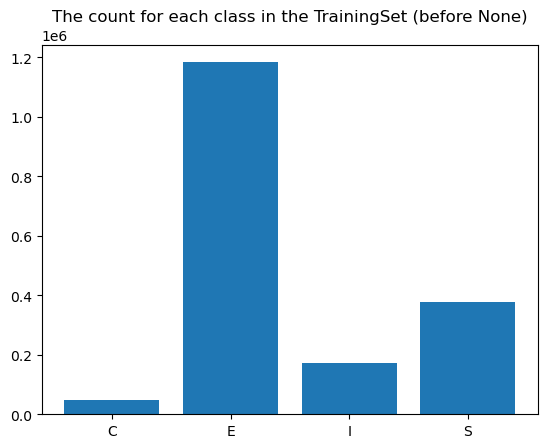

In [4]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

random_seed = 42
val_size = 0.1
technique = "None"

# Seperate data into training-, validation- and testing-set

Large_Dataset_Train = Large_Dataset.loc[Large_Dataset.split == "train", :].drop(columns = [("split", "")])
Large_Dataset_Test = Large_Dataset.loc[Large_Dataset.split == "test", :].drop(columns = [("split", "")])
Large_Dataset_Train, Large_Dataset_Val = train_test_split(Large_Dataset_Train, test_size = val_size, random_state = random_seed)
Old_size = Large_Dataset_Train.shape[0]

labels, class_counts = np.unique(Large_Dataset_Train.esci_label, return_counts = True)
string_labels = labels
fig = plt.figure()
ax = fig.add_subplot()
ax.bar(labels, class_counts)
ax.set_xticks(ticks = [i for i in range(len(labels))], labels = labels)
ax.set_title(f"The count for each class in the TrainingSet (before {technique})")
plt.show()

In [5]:
X_train, y_train = Large_Dataset_Train.iloc[:, :tensor_size*7], Large_Dataset_Train.loc[:, ("esci_label_encoded", "")]

if technique == "undersampling":
    from imblearn.under_sampling import NearMiss
    nr = NearMiss(sampling_strategy = {1 : 38359, 3: 300000, 0: 134895, 2: 294314}) # undersampling. I allow the minority class to have 10 times less samples than the majority class
    X_train, y_train = nr.fit_resample(X_train, y_train)

elif technique == "oversampling":
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(sampling_strategy='not majority', random_state = random_seed)
    X_train, y_train = smote.fit_resample(X_train, y_train)

elif technique == "both":
    from imblearn.under_sampling import NearMiss
    nr = NearMiss(sampling_strategy = {1 : 38359, 3: 300000, 0: 134895, 2: 294314}) # undersampling. I allow the minority class to have 10 times less samples than the majority class
    X_train, y_train = nr.fit_resample(X_train, y_train)
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(sampling_strategy='not majority', random_state = random_seed)
    X_train, y_train = smote.fit_resample(X_train, y_train)


Large_Dataset_Train = pd.concat((X_train, y_train), axis = 1, ignore_index = False)

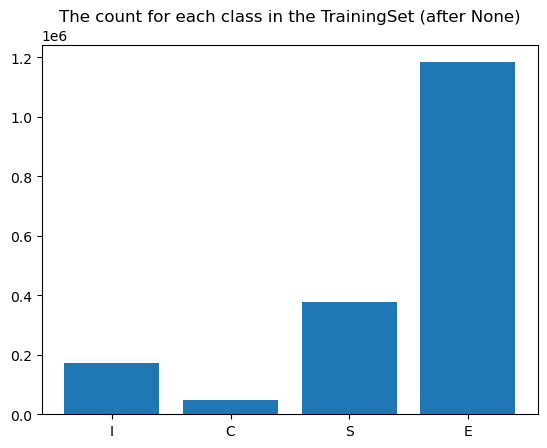

tensor([0.1952, 0.6869, 0.0893, 0.0286])
A total of 2_621_288 samples.
Size of Training Set: 1_784_944. Trainign samples lost due to undersampling: 0
Size of Validation Set: 198_328
Size of Test Set: 638_016


In [6]:
labels, class_counts = np.unique(Large_Dataset_Train.esci_label_encoded, return_counts = True)
fig = plt.figure()
ax = fig.add_subplot()
ax.bar(labels, class_counts)
ax.set_xticks(ticks = [i for i in range(len(labels))], labels = ["I", "C", "S", "E"])
ax.set_title(f"The count for each class in the TrainingSet (after {technique})")
plt.show()


total_samples = Large_Dataset_Train.shape[0]
num_classes = len(class_counts)
class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights / np.sum(class_weights)).type(torch.float)
print(class_weights)

print(f"A total of {Large_Dataset.shape[0]:_} samples.\nSize of Training Set: {Large_Dataset_Train.shape[0]:_}. Trainign samples lost due to undersampling: {Old_size - Large_Dataset_Train.shape[0]:_}\nSize of Validation Set: {Large_Dataset_Val.shape[0]:_}\nSize of Test Set: {Large_Dataset_Test.shape[0]:_}")

In [7]:
import gc
del Large_Dataset

In [8]:
from torch.utils.data import Dataset, DataLoader
import torch

class Dataset_SentenceEmbedding(Dataset):
    """
    For Sentence Embedding.
    The different product_embedding are concatenated togehter into a single tensor.
    """
    def __init__(self, Dataset):
        self.product = Dataset.iloc[:, :tensor_size*6]

        self.query = Dataset.iloc[:, tensor_size*6:tensor_size*7]
        self.esci_labelencoded = Dataset.loc[:, ("esci_label_encoded", "")]

    def __len__(self):
        return len(self.query)


    def __getitem__(self, idx):
        product = torch.tensor(self.product.iloc[idx].to_numpy().astype(np.float32))# .type(torch.long)# .squeeze(0)
        query = torch.tensor(self.query.iloc[idx].to_numpy().astype(np.float32))# .type(torch.long).squeeze(0) # shape idx
        true_label = torch.tensor(self.esci_labelencoded.iloc[idx])

        return product, query, true_label


batch_size = 256#  if torch.cuda.is_available() else 16

if torch.cuda.is_available():
    SentenceEmbedding_Train = Dataset_SentenceEmbedding(Large_Dataset_Train)
    del Large_Dataset_Train
    gc.collect()
    SentenceEmbedding_Train = DataLoader(SentenceEmbedding_Train, batch_size = batch_size, shuffle = True, pin_memory=pin_memory)

    SentenceEmbedding_Val = Dataset_SentenceEmbedding(Large_Dataset_Val)
    del Large_Dataset_Val
    gc.collect()
    SentenceEmbedding_Val = DataLoader(SentenceEmbedding_Val, batch_size = batch_size, shuffle = False, pin_memory=pin_memory)

    SentenceEmbedding_Test = Dataset_SentenceEmbedding(Large_Dataset_Test)
    del Large_Dataset_Test
    gc.collect()
    SentenceEmbedding_Test = DataLoader(SentenceEmbedding_Test, batch_size = batch_size, shuffle = False, pin_memory=pin_memory)


else:
    SentenceEmbedding_Train = Dataset_SentenceEmbedding(Large_Dataset_Train)
    del Large_Dataset_Train
    gc.collect()
    SentenceEmbedding_Train = DataLoader(SentenceEmbedding_Train, batch_size = batch_size, shuffle = True, pin_memory=False)

    SentenceEmbedding_Val = Dataset_SentenceEmbedding(Large_Dataset_Val)
    del Large_Dataset_Val
    gc.collect()
    SentenceEmbedding_Val = DataLoader(SentenceEmbedding_Val, batch_size = batch_size, shuffle = False, pin_memory=False)

    SentenceEmbedding_Test = Dataset_SentenceEmbedding(Large_Dataset_Test)
    del Large_Dataset_Test
    gc.collect()
    SentenceEmbedding_Test = DataLoader(SentenceEmbedding_Test, batch_size = batch_size, shuffle = False, pin_memory=False)

### Sentence Embedding - RNN

#### The Model(s)

In [9]:
import torch.nn as nn
import pytorch_lightning as pl
from torch.optim.lr_scheduler import ReduceLROnPlateau

class Linear_Block(nn.Module):
    """
    Linear Layer building block containing a skip connection
    """
    def __init__(self, in_nodes, out_nodes, activ = "relu"):
        super().__init__()
        self.fc1 = nn.Linear(in_nodes, in_nodes)
        self.fc2 = nn.Linear(in_nodes, out_nodes)

        self.skip = nn.Identity() if in_nodes == out_nodes else nn.Linear(in_nodes, out_nodes)

        if activ == "relu":
            self.activ_f = nn.ReLU()
            for layer in [self.fc1, self.fc2, self.skip]:
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')
        elif activ == "tanh":
            self.activ_f = nn.Tanh()
            for layer in [self.fc1, self.fc2, self.skip]:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)

        self.norm1 = nn.BatchNorm1d(in_nodes)
        self.norm2 = nn.BatchNorm1d(out_nodes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        skip = self.skip(x)
        x = self.fc1(x)
        x = self.norm1(x)
        x = self.activ_f(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.norm2(x) + skip
        x = self.activ_f(x)
        x = self.dropout(x)
        return x



class Tower(nn.Module):
    """
    The basic tower for the query and prodcuts
    """
    def __init__(self, in_nodes, out_nodes, compressed_by = 2):
        super().__init__()

        # self.compression = nn.AvgPool1d(kernel_size = compressed_by, stride = compressed_by)

        self.skip = nn.Linear(1024, out_nodes)
        self.fc1 = Linear_Block(in_nodes, 1024)
        self.fc2 = Linear_Block(1024, 768)
        self.fc3 = Linear_Block(768, 512)
        self.fc4 = Linear_Block(512, 384)
        self.out = nn.Linear(384, out_nodes)

    def forward(self, x):
        # x = self.compression(x)
        x = self.fc1(x)
        skip = self.skip(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)
        x = self.out(x) + skip

        return x


class Similarity_to_class(nn.Module):
    """
    Intakes the similarity of the product and query tower and outputs the Esci label class.
    """
    def __init__(self, in_nodes, num_classes):
        super().__init__()

        self.fc1 =  Linear_Block(in_nodes, in_nodes//2)
        self.fc2 = Linear_Block(in_nodes//2, in_nodes//4)
        self.fc3 = Linear_Block(in_nodes//4, in_nodes//8)
        self.lstm = nn.LSTM(in_nodes//8, num_classes, num_layers=3, dropout=0.2)
        # self.out = nn.Linear(64, num_classes)
        self.skip = nn.Linear(in_nodes, num_classes)
       


    def forward(self, x):
        skip = self.skip(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x, hidden = self.lstm(x)
        x = x + skip
        # x = self.out(x) + skip # logits
        return x


class Retrieval_Lightning(pl.LightningModule):
    """
    Creates two tower, one for handling the query embeddings and one for handling the product embeddings.
    Their similarity is computated using the cosine similarity. That similarity is then converted to the class-vector uitlizing LSTM.

    Parameters:
    ----------------
    out_nodes:
        Feature size of the tower-output. By default, the number of features is identitcal to the batch_size
    weights:
        Class weights for the training loss
    device:
        "cpu" or "gpu"/"cuda"
    num_classes:
        the number of features/classes in the final output
    hp:
        a class containing further hyperparameters
    """
    def __init__(self, out_nodes, weights, device, num_classes, hp):
        super().__init__()
        self.hp = hp
        self.num_classes = num_classes

        self.query_tower = Tower(in_nodes = tensor_size*1, out_nodes = out_nodes)
        self.product_tower = Tower(in_nodes = tensor_size*6, out_nodes = out_nodes)
        self.sim_to_class = Similarity_to_class(in_nodes = out_nodes, num_classes = num_classes)


        # nn.BCEWithLogitsLoss
        self.loss_fn_weighted = nn.CrossEntropyLoss(reduction = "mean", weight = weights, label_smoothing = hp.label_smoothing)# , label_smoothing = hp.label_smoothing)
        self.loss_fn_unweighted = nn.CrossEntropyLoss(reduction = "mean")
        # self.sim = nn.CosineSimilarity(dim = 1)
        # self.onehot = lambda x: nn.functional.one_hot(x, num_classes = num_classes).to(device)

        # These are for the custom logger callback
        self.training_step_outputs_loss = []
        self.validation_step_outputs_loss = []

        self.similarity_eps = torch.tensor([self.hp.similarity_eps]).to(device)

    def cosine_similarity(self, x1, x2):
        """
        This cosine similarity calculation skips the dimension reduction.
        The unreduced result will be used as input to calcualte the classes
        """
        Zähler = x1*x2
        Nenner = torch.maximum(torch.linalg.norm(x1, dim = 1), self.similarity_eps)
        Nenner *= torch.maximum(torch.linalg.norm(x2, dim = 1), self.similarity_eps)
        Nenner = Nenner[:, None]
        return Zähler/Nenner


    def configure_optimizers(self):
        # "weigth decay" is L2 Regularizer
        optimizer = torch.optim.AdamW(self.parameters(), lr= self.hp.lr, weight_decay = self.hp.l2)
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=hp.lr_decay_gamma, patience=hp.lr_decay_stepsize, threshold = hp.lr_decay_threshold)
        return  {"optimizer": optimizer, "lr_scheduler": scheduler, "monitor": "train_loss"}


    def _foundation(self, batch, weighted = True):
        """
        The basic steps that will be needed for all operations of training, validation, testing and forward.
        """
        # product and query are already sentece-embedded when provided by the DataLoader
        product, query, true_labels = batch

        query = self.query_tower(query)
        product = self.product_tower(product)
        # esci_onehot = self.onehot(esci_labels_encoded)

        # Cosine_Similarity goes from -1 (vectors completly opposite directions) to 1 (vectors are identical)
        # As I want to use the Similarity as a probability of how well the product matches the query, any similarity smaller than 0 is set to 0.
        Similarity = self.cosine_similarity(product, query)
        Prediction = self.sim_to_class(Similarity)

        if weighted:
            loss = self.loss_fn_weighted(Prediction, true_labels) # .transpose(0, 1).type(type(product))
        else:
            loss = self.loss_fn_unweighted(Prediction, true_labels) # .transpose(0, 1).type(type(product))
        return loss

    def training_step(self, batch, batch_idx):
        """
        Implement a single training period with loss function. Training loss is logged (by default to Tensorboard)
        """
        loss = self._foundation(batch, weighted = True)
        self.log("train_loss", loss)
        self.training_step_outputs_loss.append(loss.detach())
        return loss

    def validation_step(self, batch, batch_idx):
        """
        Implement a single training period with loss function. Training loss is logged (by default to Tensorboard)
        """
        loss = self._foundation(batch, weighted = False)
        # torch._dynamo.graph_break()
        self.log("val_loss", loss)
        self.validation_step_outputs_loss.append(loss.detach())
        return loss

    def test_step(self, batch, batch_idx):
        """
        Implement a single training period with loss function. Training loss is logged (by default to Tensorboard)
        """
        loss = self._foundation(batch, weighted = False)
        self.log("test_los", loss.detach())
        return loss


In [10]:
import logging
import sys

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

formatter = logging.Formatter('%(name)s : %(levelname)s:%(levelno)s  %(asctime)s    %(message)s ')

info_handler = logging.FileHandler(f"Training_Progress/Logs/{Project_Name}/info.log") # default mode is already 'append'
info_handler.setLevel(logging.INFO)
info_handler.setFormatter(formatter)
logger.addHandler(info_handler)

# Should prevent output of the logger in the command line
console_log_level = 100
console = logging.StreamHandler(sys.stdout)
console.setLevel(console_log_level)
logger.addHandler(console)

class CustomLoggerCallback(pl.Callback):
    """
    Additionally to the tensorboard-logging, I want this simple text file logging.
    """
    def on_train_epoch_end(self, trainer, pl_module):
        epoch_mean = torch.stack(pl_module.training_step_outputs_loss).mean()
        logger.info(f"Epoch {pl_module.current_epoch:0>3} Train Loss: {float(epoch_mean):.10f}")
        # free up the memory
        pl_module.training_step_outputs_loss.clear()

    def on_validation_epoch_end(self, trainer, pl_module):
        epoch_mean = torch.stack(pl_module.validation_step_outputs_loss).mean()
        logger.info(f"Epoch {pl_module.current_epoch:0>3} Valid Loss: {float(epoch_mean):.10f}")
        # free up the memory
        pl_module.validation_step_outputs_loss.clear()

In [11]:
!nvidia-smi

Der Befehl "nvidia-smi" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


#### The Trainer

In [12]:
class Hyperparameters:
    ###### In Model
    lr = 1e-3
    l2 = 1e-5
    lr_decay_gamma = 0.1
    lr_decay_stepsize = 5
    lr_decay_threshold = 1e-3
    lr_decay_parameter = "train_loss"
    label_smoothing = 0.1
    similarity_eps = 1e-10

    ## Outside of model
    # gradient_accumulation_batches = 10
    gradient_clip_val = 1.0
    Epochs = 100
    earlyStopping_min_delta = 1e-8
    earlyStopping_patience = 25
    checkPoint_Path = f"Training_Progress/Checkpoints/{Project_Name}"
    checkPoint_FilenameBase = "TwoTowerRetrieval"


In [13]:
from pytorch_lightning import Trainer, callbacks

from torch import nn
from pathlib import Path

import os

# The parameters
hp = Hyperparameters()



# The Callbacks
earlyStop = callbacks.EarlyStopping(monitor = 'val_loss',
                                    patience = hp.earlyStopping_patience,
                                    min_delta = hp.earlyStopping_min_delta)

checkPointTraining = callbacks.ModelCheckpoint(dirpath = hp.checkPoint_Path,
                                                filename = hp.checkPoint_FilenameBase +  "_{epoch}.weights",
                                                monitor='val_loss',
                                                verbose=0,
                                                save_top_k = -1,
                                                save_weights_only=False)

custom_logger = CustomLoggerCallback()

# The Trainer
trainer = Trainer(callbacks=[earlyStop, checkPointTraining, custom_logger],
                  max_epochs = hp.Epochs,
                  log_every_n_steps=1,
                  accelerator = accelerator,
                  devices = 1,
                  # precision = "16-mixed", # Mixed Precision Training for Memory and thus speed optimization
                  # accumulate_grad_batches = hp.gradient_accumulation_batches,
                  gradient_clip_val = hp.gradient_clip_val
                 )



# The Model
# Check if Training from scratch or resume training from checkpoint

checkpoints = [i for i in os.listdir(hp.checkPoint_Path)]
if ".training_done" in checkpoints:
    print("Model has already been fully trained.")
else:
    checkpoints = [i for i in checkpoints if i.endswith(".weights.ckpt")]
    if checkpoints:
        starting_epoch = np.max([int(i.split("_epoch=")[-1].replace(".weights.ckpt", "")) for i in checkpoints])
        last_checkpoint_filepath = hp.checkPoint_Path + f"/{hp.checkPoint_FilenameBase}_epoch={starting_epoch}.weights.ckpt"
        #### Apparently Google Colab can cause some sort of weird config in the pytorch safefile as it is honed for tensorflow. This causes the weights_only ckeckpoint to not be accepted when loading it
        # the serialization options allow the pytorch weights_only checkpoint to be loaded anyway
        torch.serialization.add_safe_globals([np.dtypes.Int64DType])
        with torch.serialization.safe_globals([Retrieval_Lightning, np._core.multiarray.scalar, np.dtype]):
            TwoTowerRetrievalModel = Retrieval_Lightning.load_from_checkpoint(last_checkpoint_filepath, out_nodes = batch_size, weights = class_weights, device = device, num_classes = len(esci_score_dict), hp = hp).to(device)
        trainer.fit(model = TwoTowerRetrievalModel,
                    train_dataloaders = SentenceEmbedding_Train,
                    val_dataloaders = SentenceEmbedding_Val,
                    ckpt_path=last_checkpoint_filepath
                   )
         # this empty file is used to mark that the model has already been fully trained.
        Path(f"{hp.checkPoint_Path}/.training_done").touch()
    else:
        starting_epoch = 0
        TwoTowerRetrievalModel = Retrieval_Lightning(out_nodes = batch_size, weights = class_weights, device = device, num_classes = len(esci_score_dict), hp = hp).to(device)
        trainer.fit(model = TwoTowerRetrievalModel,
                    train_dataloaders = SentenceEmbedding_Train,
                    val_dataloaders = SentenceEmbedding_Val
                   )
         # this empty file is used to mark that the model has already been fully trained.
        Path(f"{hp.checkPoint_Path}/.training_done").touch()
    
   

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


RuntimeError: Error(s) in loading state_dict for Retrieval_Lightning:
	Missing key(s) in state_dict: "query_tower.skip.weight", "query_tower.skip.bias", "query_tower.fc4.fc1.weight", "query_tower.fc4.fc1.bias", "query_tower.fc4.fc2.weight", "query_tower.fc4.fc2.bias", "query_tower.fc4.skip.weight", "query_tower.fc4.skip.bias", "query_tower.fc4.norm1.weight", "query_tower.fc4.norm1.bias", "query_tower.fc4.norm1.running_mean", "query_tower.fc4.norm1.running_var", "query_tower.fc4.norm2.weight", "query_tower.fc4.norm2.bias", "query_tower.fc4.norm2.running_mean", "query_tower.fc4.norm2.running_var", "product_tower.skip.weight", "product_tower.skip.bias", "product_tower.fc4.fc1.weight", "product_tower.fc4.fc1.bias", "product_tower.fc4.fc2.weight", "product_tower.fc4.fc2.bias", "product_tower.fc4.skip.weight", "product_tower.fc4.skip.bias", "product_tower.fc4.norm1.weight", "product_tower.fc4.norm1.bias", "product_tower.fc4.norm1.running_mean", "product_tower.fc4.norm1.running_var", "product

In [ ]:
import os
import shutil
os.makedirs(f"Best_Model_Chkpt/{Project_Name}/", exist_ok = True)
if "BestModel.save" not in os.listdir(f"Best_Model_Chkpt/{Project_Name}/"):
    ### checkPointTraining.best_model_path does unfortunatly not get restored when loading the checkpoint.
    ## As I has to pause and continue the training due to technical limitations several times,
    ## I use the .log file instead to determine the bepoch with the lowest validation loss.
    with open(f"Training_Progress/Logs/{Project_Name}/info.log", "r") as f:
        Log_content = [i.replace("\n", "").split(" ") for i in f.readlines()]
    
    Min_loss_value = np.inf
    Min_loss_epoch = None
    # First entry in the log file is from the Validiation from before the very first training epoch and is thus ignored
    for ls in Log_content:
        if ls[-4] == "Train" or int(ls[-5]) == 0:
            continue
        current_loss = float(ls[-2])
        if Min_loss_value > current_loss:
            Min_loss_value = current_loss
            Min_loss_epoch = int(ls[-5])

    
    best_model_path = f"Training_Progress/Checkpoints/{Project_Name}/TwoTowerRetrieval_epoch={Min_loss_epoch}.weights.ckpt"
    
    # Load the best model with everything
    TwoTowerRetrievalModel = Retrieval_Lightning.load_from_checkpoint(best_model_path, out_nodes = batch_size, weights = class_weights, device = device, num_classes = len(esci_score_dict), hp = hp, weights_only = False).to(device)
    saving_Trainer = Trainer(max_epochs = 0)
    saving_Trainer.fit(TwoTowerRetrievalModel, train_dataloaders = SentenceEmbedding_Train)
    saving_Trainer.save_checkpoint(f"Best_Model_Chkpt/{Project_Name}/BestModel.save", weights_only = True)
    # SAve only the the weights of the best model, as everything else was only neccessary for training
    # torch.save(TwoTowerRetrievalModel.state_dict(), f"/Best_Model_Chkpt/{Project_Name}/BestModel.save")

In [ ]:
TwoTowerRetrievalModel = Retrieval_Lightning.load_from_checkpoint(f"Best_Model_Chkpt/{Project_Name}/BestModel.save", out_nodes = batch_size, weights = class_weights, device = device, num_classes = len(esci_score_dict), hp = hp, weights_only = True).to(device)